In [1]:
#  importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# read the dataset file 
df = pd.read_csv("dataset.csv")


In [3]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap',
       'timestamp', 'crypto_name', 'date'],
      dtype='object')

In [4]:
# drop the unnamed column 
df = df.drop(columns=["Unnamed: 0"],errors='ignore')

In [5]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp',
       'crypto_name', 'date'],
      dtype='object')

In [6]:
# convert the date and timestamp column to datetime format
import datetime
df['date'] = pd.to_datetime(df['date'])

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [8]:
# sort the dataframe by crypto_name and date
df = df.sort_values(['crypto_name','date'])

In [9]:
df.shape

(72946, 9)

In [10]:
# filter the dataframe for a specific cryptocurrency
crypto = 'Bitcoin'
df = df[df['crypto_name']== crypto].copy()
print(df.head())

         open        high         low       close  volume     marketCap  \
0  112.900002  118.800003  107.142998  115.910004     0.0  1.288693e+09   
2  115.980003  124.663002  106.639999  112.300003     0.0  1.249023e+09   
4  112.250000  113.444000   97.699997  111.500000     0.0  1.240594e+09   
7  109.599998  115.779999  109.599998  113.566002     0.0  1.264049e+09   
9  113.199997  113.459999  109.260002  112.669998     0.0  1.254535e+09   

                         timestamp crypto_name       date  
0 2013-05-05 23:59:59.999000+00:00     Bitcoin 2013-05-05  
2 2013-05-06 23:59:59.999000+00:00     Bitcoin 2013-05-06  
4 2013-05-07 23:59:59.999000+00:00     Bitcoin 2013-05-07  
7 2013-05-08 23:59:59.999000+00:00     Bitcoin 2013-05-08  
9 2013-05-09 23:59:59.999000+00:00     Bitcoin 2013-05-09  


FEATURE ENGINEERING

In [11]:
# calculate the daily returns of the cryptocurrency
df['return'] = df['close'].pct_change()

In [12]:
# calculate the rolling volatility (standard deviation of returns) over a 7-day window
# the target variable is the rolling volatility shifted by one day (i.e., the volatility of the next day)
df['rolling_volatility'] = df['return'].rolling(window=7).std()
df['target'] = df['rolling_volatility'].shift(-1)

In [13]:
# calculate the moving averages of the closing price over 7-day and 30-day windows  
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_30'] = df['close'].rolling(window=30).mean()

In [14]:
# calculate the liquidity ratio as volume divided by market capitalization
df['liquidity_ratio'] = df['volume']/ df['marketCap']

In [15]:
# calculate the Bollinger Bands (upper and lower) using a 20-day rolling mean and standard deviation
rolling_mean = df['close'].rolling(window=20).mean()
rolling_std = df['close'].rolling(window=20).std()

df['bb_upper'] = rolling_mean + 2 * rolling_std
df['bb_lower'] = rolling_mean - 2 * rolling_std

In [16]:
# calculate the Average True Range (ATR) as a measure of volatility
df['range'] = df['high'] - df['low']
df['high_close'] = (df['high'] - df['close'].shift(1))
df['low_close'] = (df['low'] - df['close'].shift(1))

df['true_range'] = df[['range','high_close','low_close']].max(axis=1)
df['atr_14'] = df['true_range'].rolling(window=14).mean()

In [17]:
# drop the rows with missing values (due to rolling calculations)
df = df.dropna()

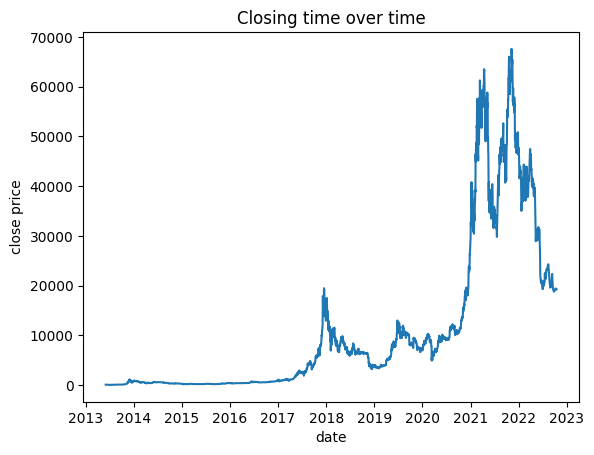

In [18]:
# visualize the closing price over time
plt.figure()
plt.plot(df['date'],df['close'])
plt.title("Closing time over time")
plt.xlabel('date')
plt.ylabel('close price')
plt.show()

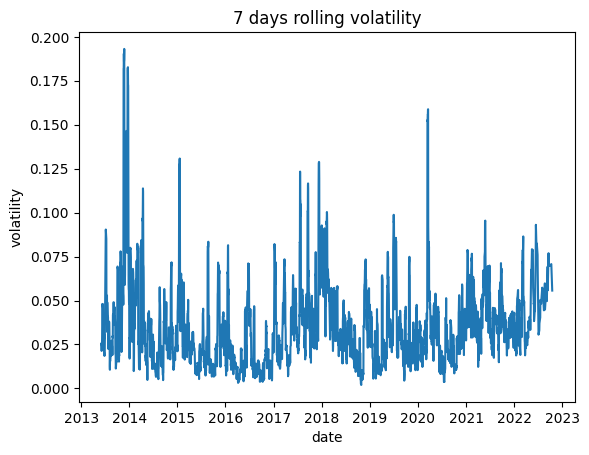

In [19]:
# visualize the 7-day rolling volatility over time
plt.figure()
plt.plot(df['date'],df['rolling_volatility'])
plt.title("7 days rolling volatility")
plt.xlabel('date')
plt.ylabel('volatility')
plt.show()

In [20]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp',
       'crypto_name', 'date', 'return', 'rolling_volatility', 'target', 'ma_7',
       'ma_30', 'liquidity_ratio', 'bb_upper', 'bb_lower', 'range',
       'high_close', 'low_close', 'true_range', 'atr_14'],
      dtype='object')

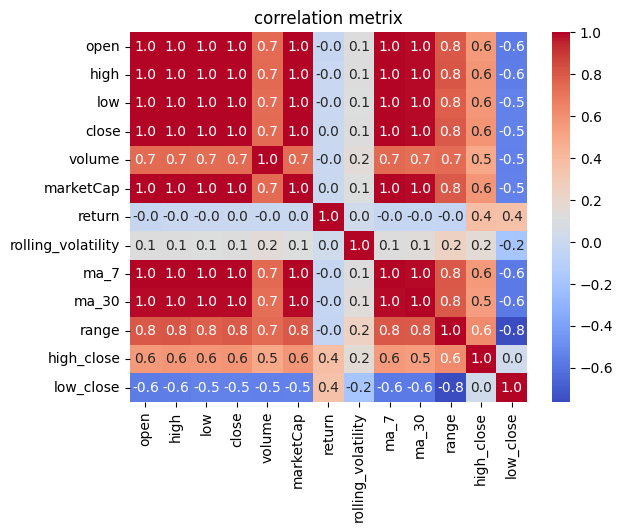

In [21]:
# visualize the correlation matrix of the features and the target variable
plt.figure()
sns.heatmap(df[['open', 'high', 'low', 'close', 'volume', 'marketCap','return', 'rolling_volatility',
                'ma_7', 'ma_30','range','high_close','low_close']].corr(),cmap='coolwarm'
            ,annot=True,fmt='.1f')
plt.title('correlation metrix')
plt.show()

In [22]:
# select the features and the target variable for modeling
feature = ['open','high','low','close','volume','marketCap','ma_7',
           'ma_30','liquidity_ratio','bb_upper','bb_lower','atr_14']
X = df[feature]
y= df['target']

In [23]:
# split the data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
print(X_train.shape)
print(y_train.shape)

(2574, 12)
(2574,)


In [25]:
# build a linear regression model using a pipeline with standard scaling
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
lr_pred = lr_pipeline.predict(X_test)

In [26]:
# build a random forest regression model with hyperparameter tuning using grid search and time series cross-validation
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5]
}
tscv = TimeSeriesSplit(n_splits=5)

grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train,y_train)
best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

print("Best RF Params",grid_rf.best_params_)

Best RF Params {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [27]:
# build an XGBoost regression model with hyperparameter tuning using grid search and time series cross-validation
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
}
grid_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_xgb.fit(X_train,y_train)
best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)
print("Best XGB Params:",grid_xgb.best_params_)

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [28]:
# evaluate the models using RMSE, MAE, and R2 score
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

In [29]:
# evaluate the models
evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")


Linear Regression
RMSE: 0.02390297847813928
MAE : 0.016271649268303167
R2  : 0.08698675547105372

Random Forest
RMSE: 0.01166581931523117
MAE : 0.00769632471314967
R2  : 0.782527910134703

XGBoost
RMSE: 0.012296008641521874
MAE : 0.008453997627984787
R2  : 0.7583975376705062


In [30]:
# print the R2 scores for the training and testing sets for the linear regression model
print("Linear Regression")
print("Train R2:", lr_pipeline.score(X_train, y_train))
print("Test R2 :", lr_pipeline.score(X_test, y_test))

Linear Regression
Train R2: 0.18165741141484426
Test R2 : 0.08698675547105372


In [31]:
# print the R2 scores for the training and testing sets for the random forest model
print("Random Forest")
print("Train R2:", best_rf.score(X_train, y_train))
print("Test R2 :", best_rf.score(X_test, y_test))

Random Forest
Train R2: 0.9728705089493249
Test R2 : 0.782527910134703


In [32]:
# print the R2 scores for the training and testing sets for the XGBoost model
print("XGBoost")
print("Train R2:", best_xgb.score(X_train, y_train))
print("Test R2 :", best_xgb.score(X_test, y_test))

XGBoost
Train R2: 0.940733314806497
Test R2 : 0.7583975376705062


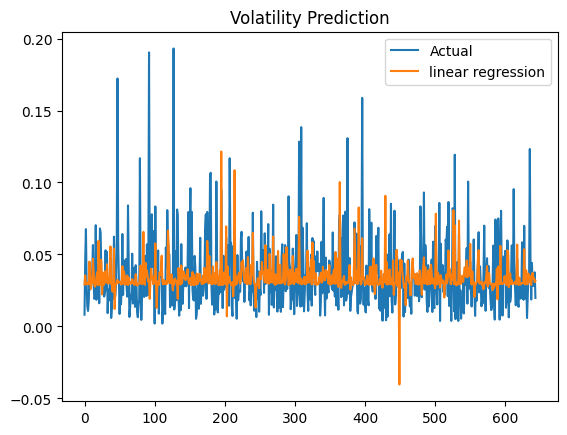

In [33]:
# visualize the actual vs predicted values for the linear regression model
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(lr_pred, label="linear regression")
plt.legend()
plt.title("Volatility Prediction")
plt.show()

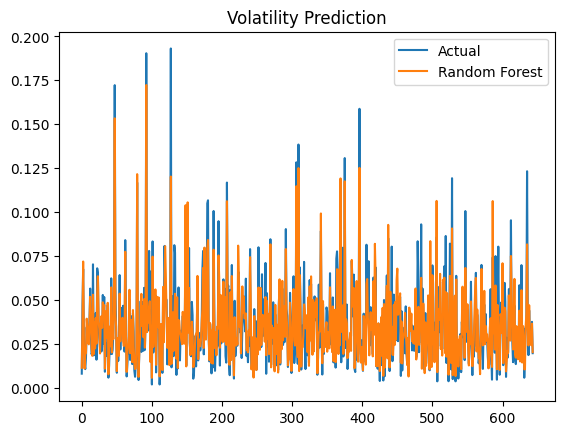

In [34]:
# visualize the actual vs predicted values for the random forest model
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(rf_pred, label="Random Forest")
plt.legend()
plt.title("Volatility Prediction")
plt.show()

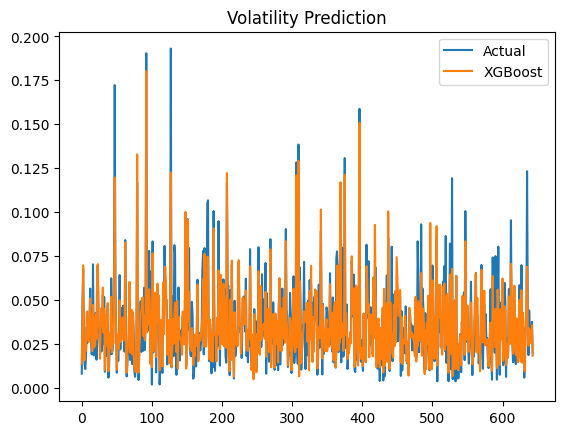

In [35]:
# visualize the actual vs predicted values for the XGBoost model
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="XGBoost")
plt.legend()
plt.title("Volatility Prediction")
plt.show()

In [36]:
# save the best performing model (random forest) to a file using joblib
import joblib

joblib.dump(best_rf, 'final_model.pkl')
print("Model saved as final_model.pkl")

Model saved as final_model.pkl


In [37]:
joblib.dump(feature,'model_features.pkl')

['model_features.pkl']

In [38]:
#  do this for loading the model and features in a new script or notebook
# joblib.load('final_model.pkl')
# joblib.load('model_features.pkl')

In [39]:
# for making predictions with the loaded model

# new_data = X_test.iloc[:1]  # sample row

# prediction = loaded_model.predict(new_data)

# print("Predicted Volatility:", prediction[0])